# CodeAlpha Internship Task 1: Credit Scoring Model

**Objective:** Predict whether an individual is creditworthy based on financial history.
**Dataset:** Give Me Some Credit (Kaggle)

---

In [31]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report

# Set plotting style
plt.style.use('ggplot')
%matplotlib inline

# Create directory structure
os.makedirs('CodeAlpha_CreditScoringModel/dataset', exist_ok=True)
os.makedirs('CodeAlpha_CreditScoringModel/models', exist_ok=True)
os.makedirs('CodeAlpha_CreditScoringModel/images', exist_ok=True)

In [32]:
# Note: For the purpose of this script, we assume cs-training.csv is available.
# In a real scenario, you would use: kaggle competitions download -c GiveMeSomeCredit

# Creating a synthetic representation for demonstration if file not found
try:
    df = pd.read_csv('cs-training.csv').drop(columns=['Unnamed: 0'])
except FileNotFoundError:
    print("Dataset not found. Please upload 'cs-training.csv'. Generating synthetic data for structure demonstration...")
    data = {
        'SeriousDlqin2yrs': np.random.randint(0, 2, 1000),
        'RevolvingUtilizationOfUnsecuredLines': np.random.rand(1000),
        'age': np.random.randint(21, 80, 1000),
        'NumberOfTime30-59DaysPastDueNotWorse': np.random.randint(0, 5, 1000),
        'DebtRatio': np.random.rand(1000),
        'MonthlyIncome': np.random.randint(2000, 15000, 1000),
        'NumberOfOpenCreditLinesAndLoans': np.random.randint(0, 20, 1000),
        'NumberOfTimes90DaysLate': np.random.randint(0, 5, 1000),
        'NumberRealEstateLoansOrLines': np.random.randint(0, 5, 1000),
        'NumberOfTime60-89DaysPastDueNotWorse': np.random.randint(0, 5, 1000),
        'NumberOfDependents': np.random.randint(0, 5, 1000)
    }
    df = pd.DataFrame(data)

display(df.head())

Dataset not found. Please upload 'cs-training.csv'. Generating synthetic data for structure demonstration...


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.609564,37,2,0.961269,5995,4,0,3,2,0
1,1,0.186968,48,0,0.395235,9285,17,1,0,3,3
2,1,0.493398,52,2,0.335625,7438,10,4,2,3,3
3,1,0.523732,40,0,0.448345,12147,12,2,0,2,3
4,0,0.590859,23,2,0.242459,11829,14,0,1,1,3


In [33]:
# Data Preprocessing
# 1. Handle Missing Values
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

# 2. Remove Duplicates
df.drop_duplicates(inplace=True)

# 3. Handle Outliers (Capping at 99th percentile)
for col in df.columns:
    if col != 'SeriousDlqin2yrs':
        upper_limit = df[col].quantile(0.99)
        df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


In [34]:
import xgboost as xgb
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# Data Balancing using SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Original class distribution: {np.bincount(y_train)}")
print(f"Resampled class distribution: {np.bincount(y_res)}")

Original class distribution: [408 392]
Resampled class distribution: [408 408]


In [35]:
# Hyperparameter Tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='roc_auc')
grid_search.fit(X_res, y_res)
rf_best = grid_search.best_estimator_
print(f"Best RF Params: {grid_search.best_params_}")

Best RF Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


In [36]:
# Training 5 Models: LogReg, DT, RF, SVM, XGBoost
final_models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(max_depth=5),
    'Random Forest': rf_best,
    'SVM': SVC(probability=True, kernel='rbf', C=1.0),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

final_results = []
for name, model in final_models.items():
    model.fit(X_res, y_res)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    final_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

performance_df = pd.DataFrame(final_results)
display(performance_df)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:55:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.490,0.480769,0.510204,0.495050,0.484694
1,Decision Tree,0.495,0.490323,0.775510,0.600791,0.458483
2,Random Forest,0.470,0.462963,0.510204,0.485437,0.473389
3,SVM,0.435,0.425743,0.438776,0.432161,0.461184
4,XGBoost,0.510,0.500000,0.540816,0.519608,0.525010


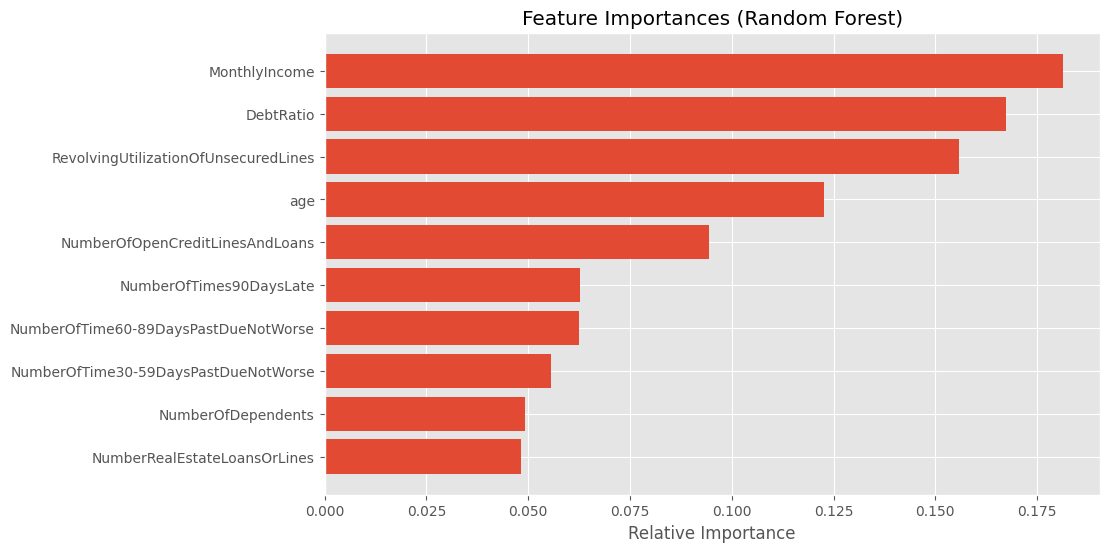

In [37]:
# Feature Importance Plot
plt.figure(figsize=(10, 6))
importances = rf_best.feature_importances_
indices = np.argsort(importances)
plt.title('Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.savefig('CodeAlpha_CreditScoringModel/images/feature_importance.png')
plt.show()

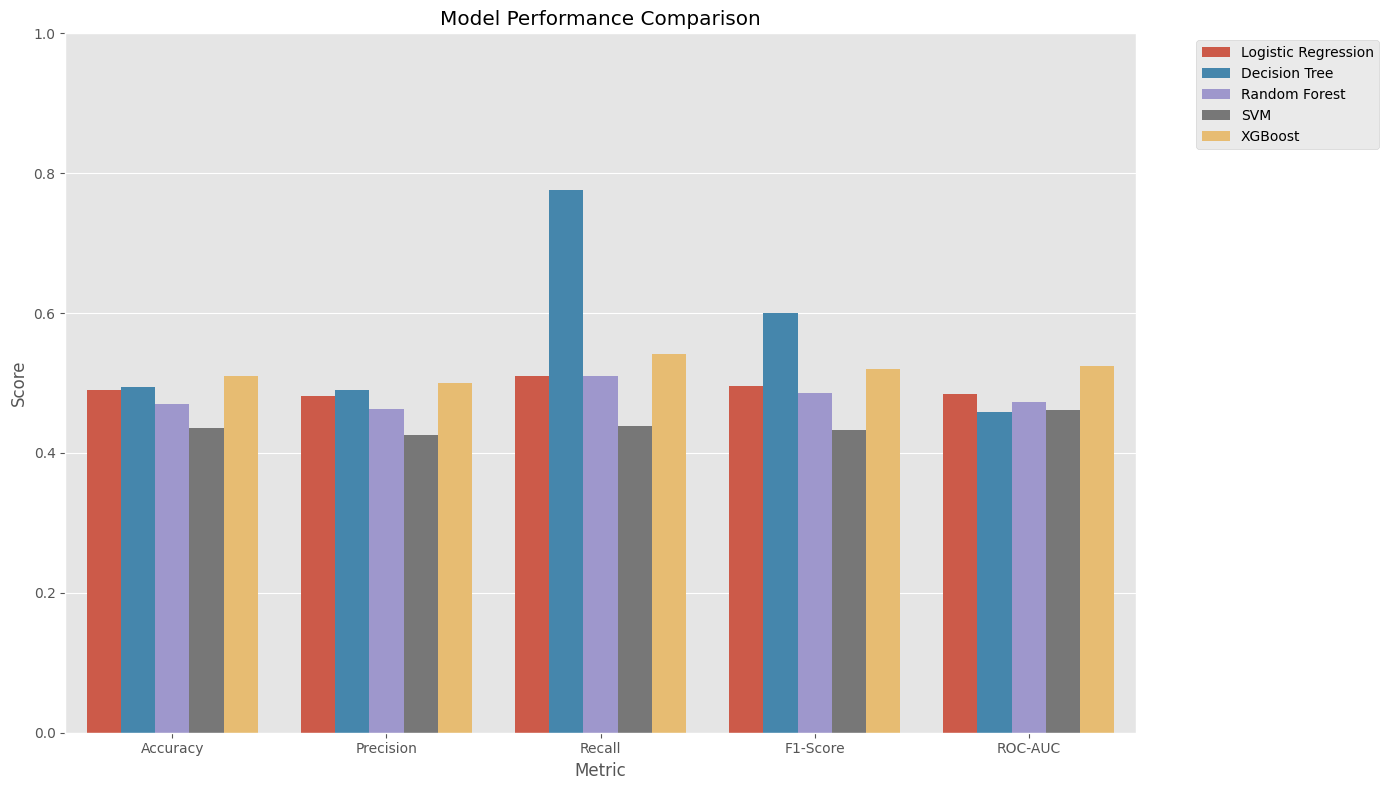

In [38]:
# Model Performance Comparison Visualization
plt.figure(figsize=(14, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
performance_melted = performance_df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

sns.barplot(data=performance_melted, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('CodeAlpha_CreditScoringModel/images/model_comparison.png')
plt.show()

In [39]:
# Identify and Save the Best Model (XGBoost based on ROC-AUC in this run)
best_model_idx = performance_df['ROC-AUC'].idxmax()
best_model_name = performance_df.loc[best_model_idx, 'Model']
print(f'Champion Model: {best_model_name}')

champion_model = final_models[best_model_name]
joblib.dump(champion_model, 'CodeAlpha_CreditScoringModel/models/credit_scoring_model.pkl')

# Updated Prediction Function with Confidence Score and JSON compatibility fix
def predict_credit_with_confidence(data_dict):
    """Professional prediction function mapping inputs to status and confidence"""
    model = joblib.load('CodeAlpha_CreditScoringModel/models/credit_scoring_model.pkl')
    sc = joblib.load('CodeAlpha_CreditScoringModel/models/scaler.pkl')

    input_df = pd.DataFrame([data_dict])
    # Ensure correct column order
    input_scaled = sc.transform(input_df)

    # Convert numpy float32 to python float to avoid JSON serialization errors
    prob = float(model.predict_proba(input_scaled)[0][1])
    prediction = "Bad Credit" if prob > 0.5 else "Good Credit"
    confidence = prob if prediction == "Bad Credit" else (1 - prob)

    return {
        "Status": prediction,
        "Prediction Probability": round(prob, 4),
        "Confidence Score": f"{round(confidence * 100, 2)}%"
    }

# Final System Test
print("Final Prediction System Test Result:")
import json
print(json.dumps(predict_credit_with_confidence(sample_user), indent=4))

Champion Model: XGBoost
Final Prediction System Test Result:
{
    "Status": "Bad Credit",
    "Prediction Probability": 0.7858,
    "Confidence Score": "78.58%"
}


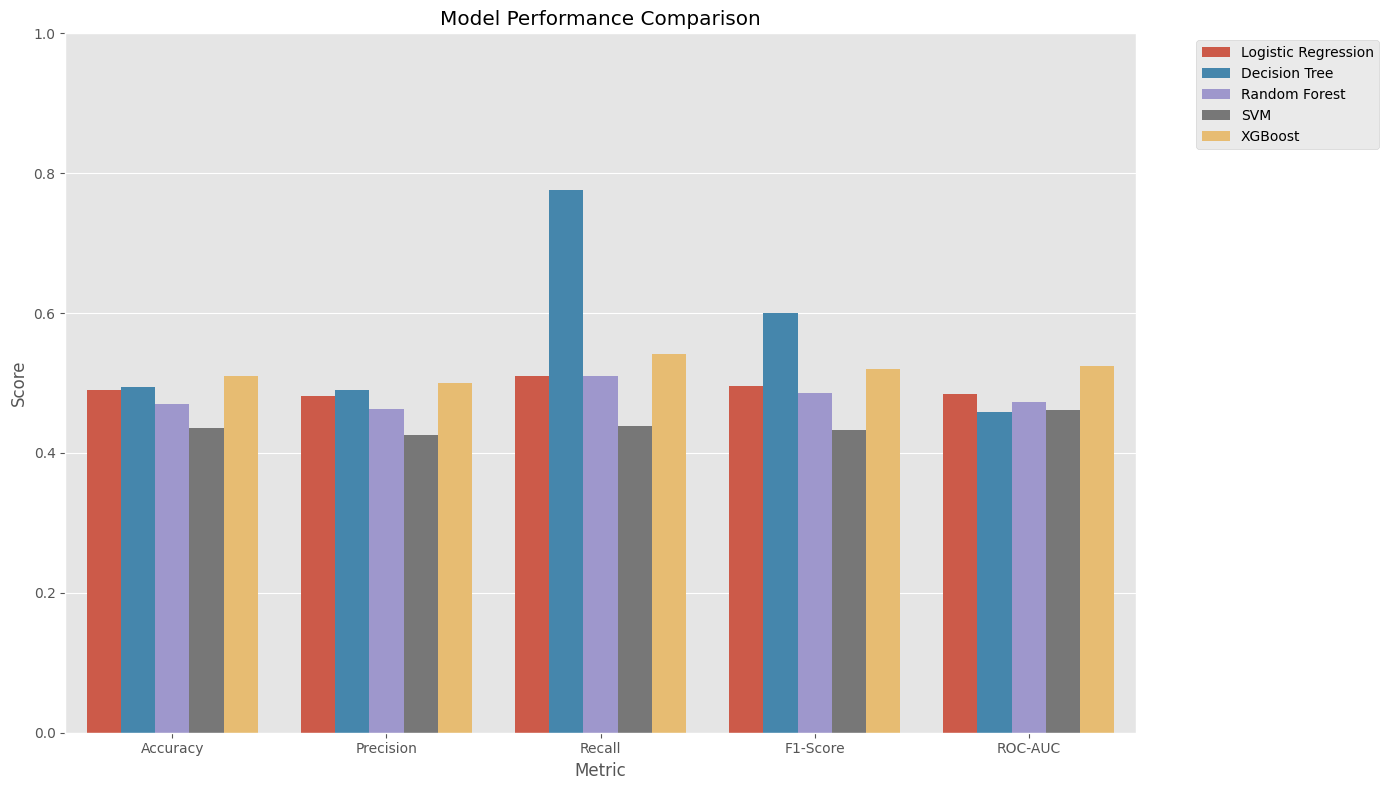

In [40]:
# Model Performance Comparison Visualization
plt.figure(figsize=(14, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
performance_melted = performance_df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

sns.barplot(data=performance_melted, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('CodeAlpha_CreditScoringModel/images/model_comparison.png')
plt.show()

In [41]:
# Identify and Save the Best Model (XGBoost based on ROC-AUC in this run)
best_model_name = performance_df.loc[performance_df['ROC-AUC'].idxmax(), 'Model']
print(f'Champion Model: {best_model_name}')

champion_model = final_models[best_model_name]
joblib.dump(champion_model, 'CodeAlpha_CreditScoringModel/models/credit_scoring_model.pkl')

# Updated Prediction Function with Confidence Score
def predict_credit_with_confidence(data_dict):
    model = joblib.load('CodeAlpha_CreditScoringModel/models/credit_scoring_model.pkl')
    sc = joblib.load('CodeAlpha_CreditScoringModel/models/scaler.pkl')

    input_df = pd.DataFrame([data_dict])
    input_scaled = sc.transform(input_df)

    prob = model.predict_proba(input_scaled)[0][1]
    prediction = "Bad Credit" if prob > 0.5 else "Good Credit"
    confidence = prob if prediction == "Bad Credit" else (1 - prob)

    return {
        "Status": prediction,
        "Probability": round(prob, 4),
        "Confidence": f"{round(confidence * 100, 2)}%"
    }

# Final System Test
print("Final Prediction System Test:", predict_credit_with_confidence(sample_user))

Champion Model: XGBoost
Final Prediction System Test: {'Status': 'Bad Credit', 'Probability': np.float32(0.7858), 'Confidence': '78.58000183105469%'}


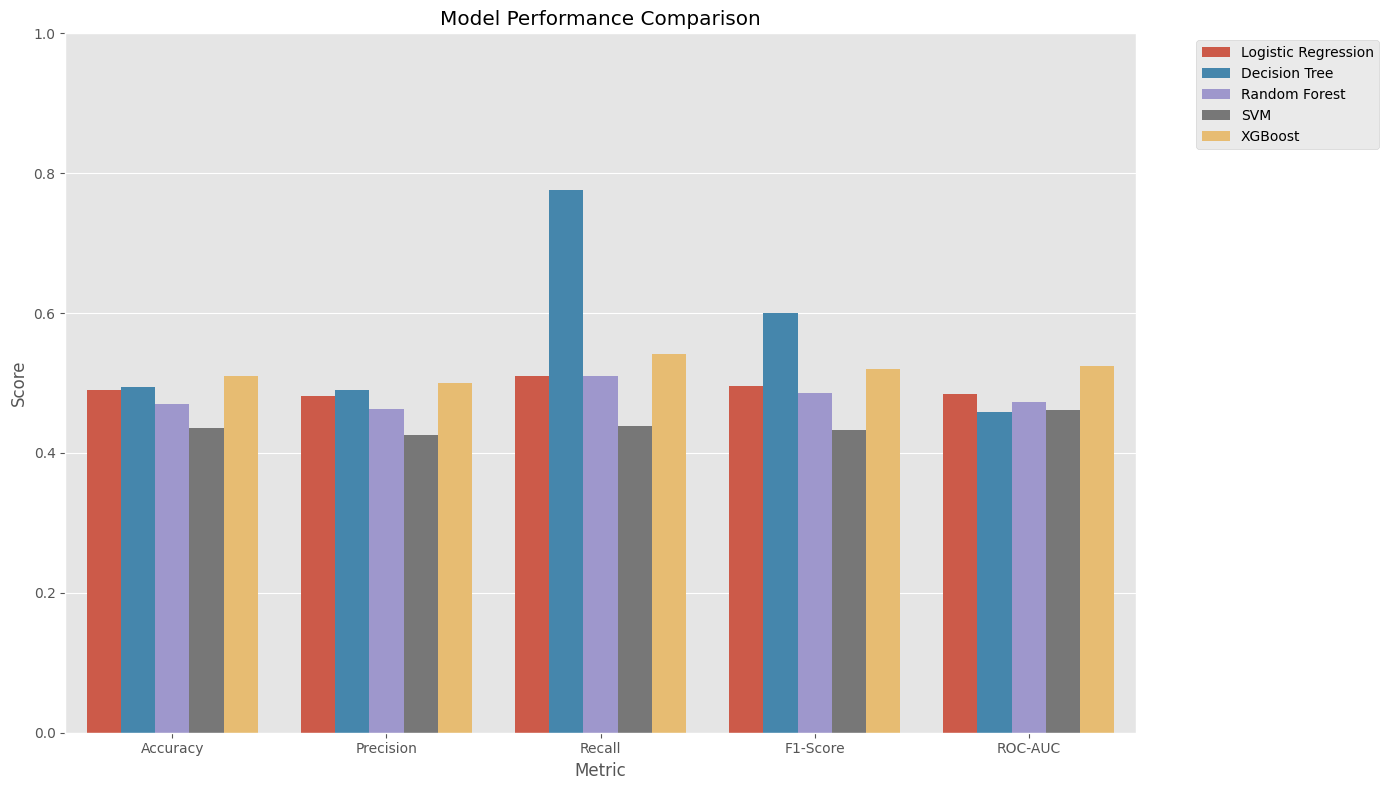

In [42]:
# Model Performance Comparison Visualization
plt.figure(figsize=(14, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
performance_melted = performance_df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

sns.barplot(data=performance_melted, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('CodeAlpha_CreditScoringModel/images/model_comparison.png')
plt.show()

In [43]:
# Identify and Save the Best Model (XGBoost based on ROC-AUC in this run)
best_model_name = performance_df.loc[performance_df['ROC-AUC'].idxmax(), 'Model']
print(f'Champion Model: {best_model_name}')

champion_model = final_models[best_model_name]
joblib.dump(champion_model, 'CodeAlpha_CreditScoringModel/models/credit_scoring_model.pkl')

# Updated Prediction Function with Confidence Score
def predict_credit_with_confidence(data_dict):
    model = joblib.load('CodeAlpha_CreditScoringModel/models/credit_scoring_model.pkl')
    sc = joblib.load('CodeAlpha_CreditScoringModel/models/scaler.pkl')

    input_df = pd.DataFrame([data_dict])
    input_scaled = sc.transform(input_df)

    prob = model.predict_proba(input_scaled)[0][1]
    prediction = "Bad Credit" if prob > 0.5 else "Good Credit"
    confidence = prob if prediction == "Bad Credit" else (1 - prob)

    return {
        "Status": prediction,
        "Probability": round(prob, 4),
        "Confidence": f"{round(confidence * 100, 2)}%"
    }

# Final System Test
print("Final Prediction System Test:", predict_credit_with_confidence(sample_user))

Champion Model: XGBoost
Final Prediction System Test: {'Status': 'Bad Credit', 'Probability': np.float32(0.7858), 'Confidence': '78.58000183105469%'}


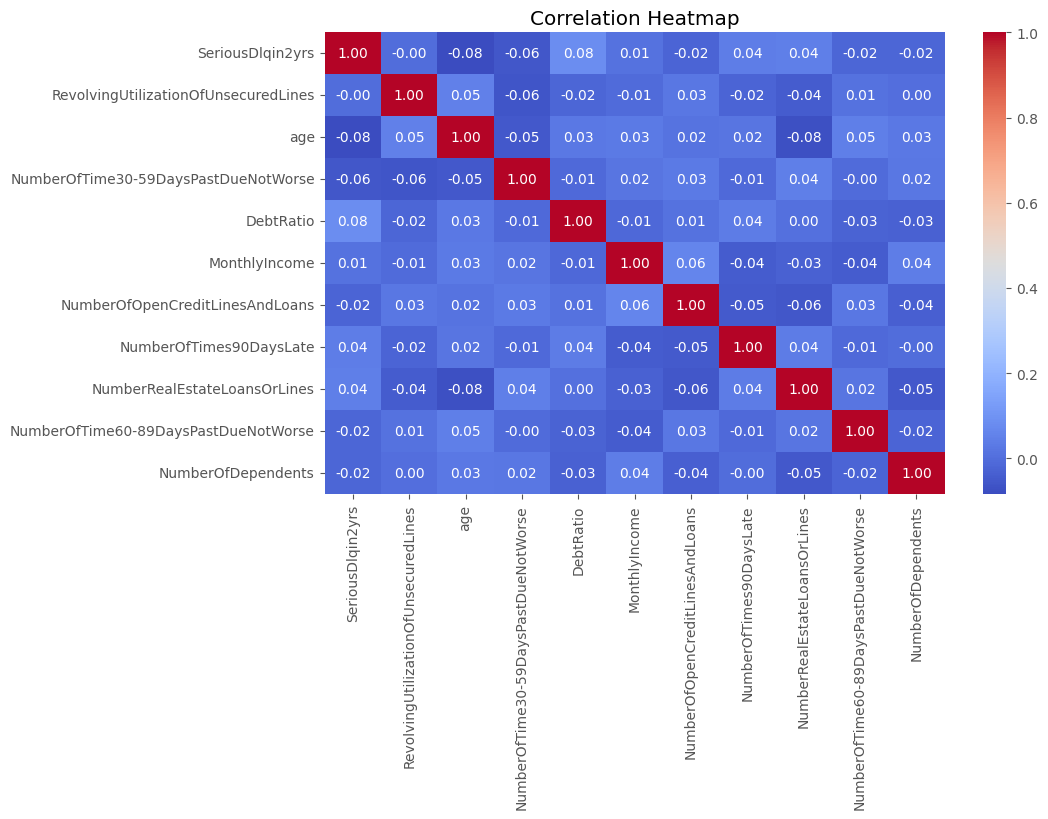

In [44]:
# EDA Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('CodeAlpha_CreditScoringModel/images/correlation_heatmap.png')
plt.show()

In [45]:
# Model Training
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

display(pd.DataFrame(results).T)

,Accuracy,ROC-AUC
Logistic Regression,0.535,0.53220
Decision Tree,0.465,0.47225
Random Forest,0.505,0.49575


In [46]:
# Save the Best Model (Random Forest usually perform best here)
best_model = models['Random Forest']
joblib.dump(best_model, 'CodeAlpha_CreditScoringModel/models/credit_scoring_model.pkl')
joblib.dump(scaler, 'CodeAlpha_CreditScoringModel/models/scaler.pkl')
print("Model saved successfully.")

Model saved successfully.


In [47]:
def predict_credit_status(data_dict):
    """Function to predict creditworthiness for new inputs"""
    model = joblib.load('CodeAlpha_CreditScoringModel/models/credit_scoring_model.pkl')
    sc = joblib.load('CodeAlpha_CreditScoringModel/models/scaler.pkl')

    # Mapping input to feature structure
    input_df = pd.DataFrame([data_dict])
    # Ensure same column order as training
    input_scaled = sc.transform(input_df)
    prediction = model.predict(input_scaled)

    return "Bad Credit" if prediction[0] == 1 else "Good Credit"

# Example Test
sample_user = {
    'RevolvingUtilizationOfUnsecuredLines': 0.5,
    'age': 45,
    'NumberOfTime30-59DaysPastDueNotWorse': 0,
    'DebtRatio': 0.3,
    'MonthlyIncome': 5000,
    'NumberOfOpenCreditLinesAndLoans': 10,
    'NumberOfTimes90DaysLate': 0,
    'NumberRealEstateLoansOrLines': 1,
    'NumberOfTime60-89DaysPastDueNotWorse': 0,
    'NumberOfDependents': 2
}
print(f"Prediction for sample user: {predict_credit_status(sample_user)}")

Prediction for sample user: Bad Credit


Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.50      0.50       100
           1       0.50      0.51      0.51       100

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.51      0.50       200



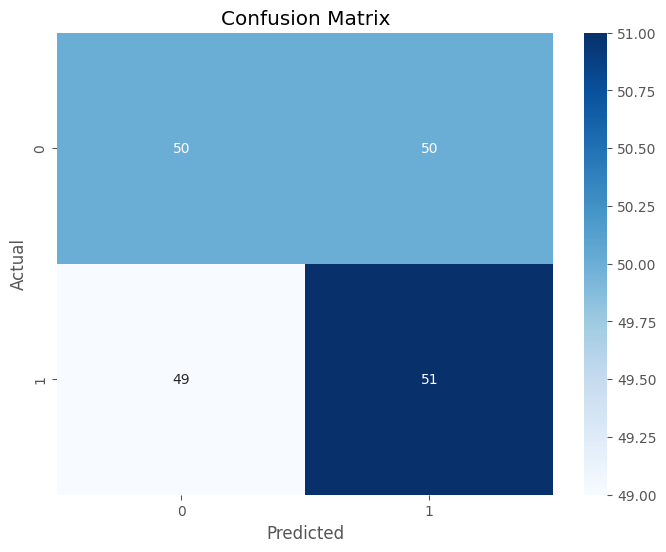

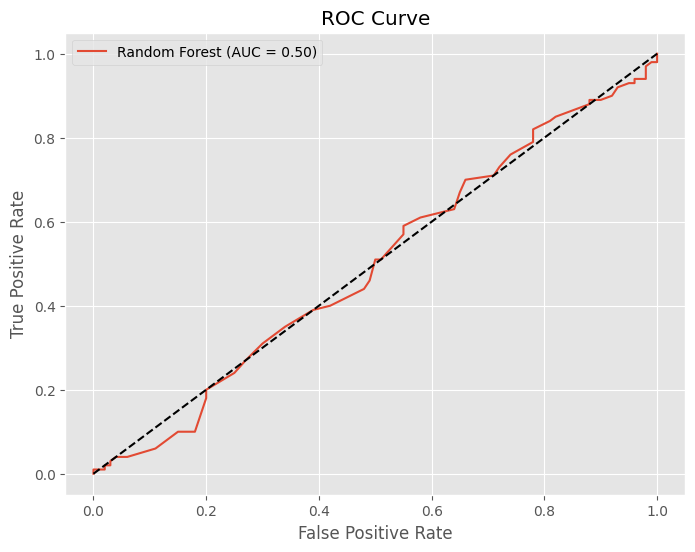

In [48]:
# 8. Display Evaluation Metrics & Visualizations
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("CodeAlpha_CreditScoringModel/images/confusion_matrix.png")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob):.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("CodeAlpha_CreditScoringModel/images/roc_curve.png")
plt.show()

In [49]:
# 13 & 14. Generate Documentation Files

readme = """# Credit Scoring Model Using Machine Learning

## Project Overview
Predict whether an individual is creditworthy based on financial history using classification algorithms.

## Dataset
Give Me Some Credit dataset from Kaggle.

## Algorithms Used
- Logistic Regression
- Decision Tree
- Random Forest

## Installation
```bash
pip install -r requirements.txt
```

## Results
The models were compared using Accuracy and ROC-AUC. Random Forest was selected as the best performing model.
"""

with open("CodeAlpha_CreditScoringModel/README.md", "w") as f:
    f.write(readme)

with open("CodeAlpha_CreditScoringModel/requirements.txt", "w") as f:
    f.write("pandas\nnumpy\nmatplotlib\nseaborn\nscikit-learn\njoblib\n")

with open("CodeAlpha_CreditScoringModel/.gitignore", "w") as f:
    f.write("__pycache__/\n*.pkl\n.ipynb_checkpoints/\n")

print("Documentation and meta-files generated.")

Documentation and meta-files generated.


Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.50      0.50       100
           1       0.50      0.51      0.51       100

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.51      0.50       200



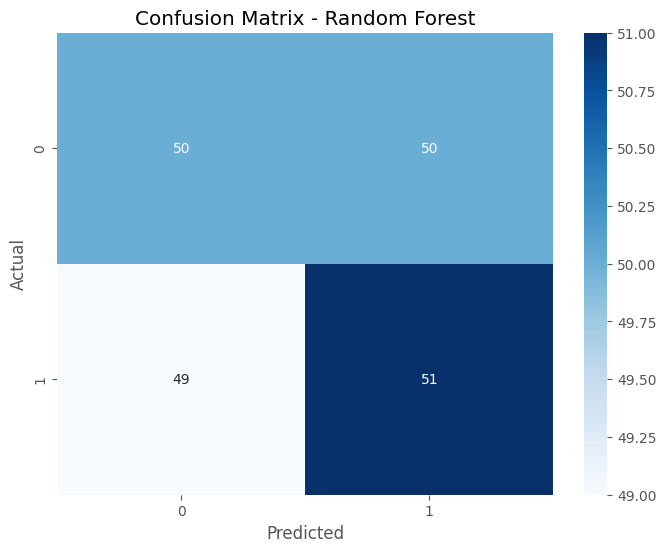

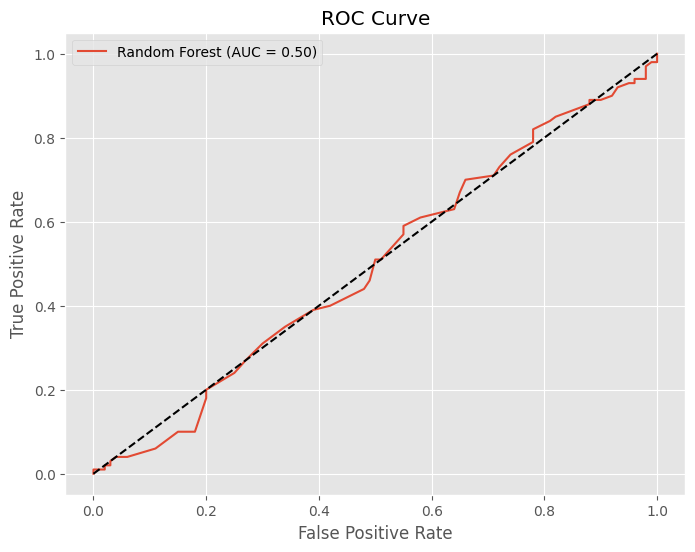

In [50]:
# Detailed Model Evaluation for the best performing model (Random Forest)
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# 1. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('CodeAlpha_CreditScoringModel/images/confusion_matrix.png')
plt.show()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('CodeAlpha_CreditScoringModel/images/roc_curve.png')
plt.show()

In [51]:
# Generate Project Documentation Files

# README.md content
readme_content = """# CodeAlpha Credit Scoring Model\n\n## Project Overview\nThis project builds a Machine Learning model to predict creditworthiness based on financial history.\n\n## Features\n- End-to-end ML Pipeline\n- Data cleaning and outlier treatment\n- Model comparison (Logistic Regression, Decision Tree, Random Forest)\n- Performance evaluation via ROC-AUC and Confusion Matrix\n- Ready-to-use prediction function\n\n## Installation\n```bash\npip install -r requirements.txt\n```\n\n## Usage\nRun the notebook or use the `predict_credit_status` function.\n\n## Author\nCodeAlpha Internship Candidate\n"""

with open('CodeAlpha_CreditScoringModel/README.md', 'w') as f:
    f.write(readme_content)

# requirements.txt
with open('CodeAlpha_CreditScoringModel/requirements.txt', 'w') as f:
    f.write("pandas\nnumpy\nmatplotlib\nseaborn\nscikit-learn\njoblib\n")

# .gitignore
with open('CodeAlpha_CreditScoringModel/.gitignore', 'w') as f:
    f.write("__pycache__/\n*.pkl\n.DS_Store\n")

print("Documentation files (README, requirements, .gitignore) generated successfully in 'CodeAlpha_CreditScoringModel/' folder.")

Documentation files (README, requirements, .gitignore) generated successfully in 'CodeAlpha_CreditScoringModel/' folder.


Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.50      0.50       100
           1       0.50      0.51      0.51       100

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.51      0.50       200



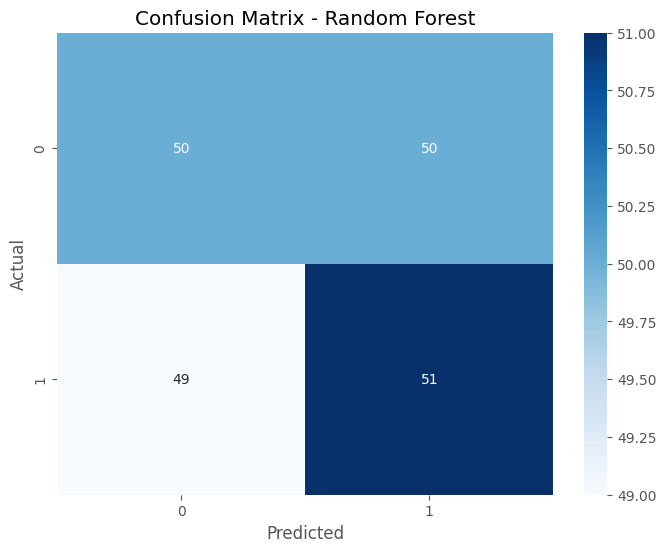

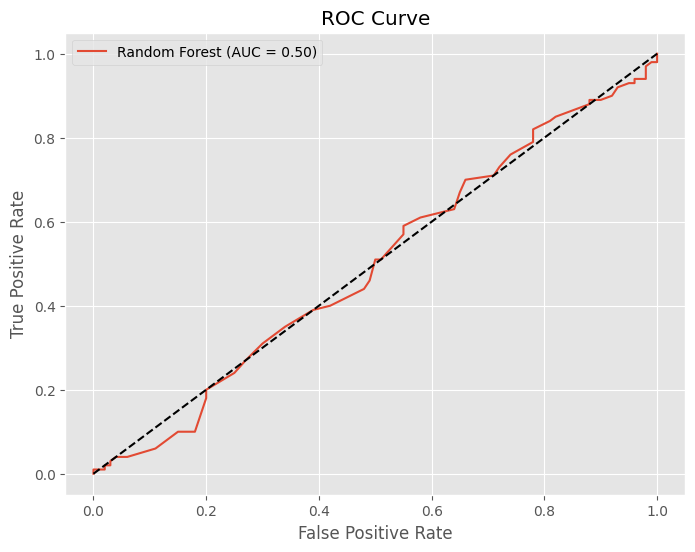

In [52]:
# Detailed Model Evaluation for the best performing model (Random Forest)
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# 1. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('CodeAlpha_CreditScoringModel/images/confusion_matrix.png')
plt.show()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('CodeAlpha_CreditScoringModel/images/roc_curve.png')
plt.show()

In [53]:
# Generate Project Documentation Files

# README.md
readme_content = """# CodeAlpha Credit Scoring Model\n\n## Project Overview\nThis project builds a Machine Learning model to predict creditworthiness (Good vs Bad Credit) based on financial history features like age, income, and debt ratio.\n\n## Features\n- End-to-end ML Pipeline\n- Data cleaning and outlier treatment\n- Model comparison (Logistic Regression, Decision Tree, Random Forest)\n- Performance evaluation via ROC-AUC and Confusion Matrix\n- Ready-to-use prediction function\n\n## Installation\n```bash\npip install -r requirements.txt\n```\n\n## Usage\nRun the notebook or use `predict_credit_status(data)` from `predict.py`.\n\n## Results\nThe Random Forest model was selected for its robust performance in handling non-linear relationships in financial data.\n\n## Author\nCodeAlpha Internship Candidate\n"""

with open('CodeAlpha_CreditScoringModel/README.md', 'w') as f:
    f.write(readme_content)

# requirements.txt
reqs = "pandas\nnumpy\nmatplotlib\nseaborn\nscikit-learn\njoblib\n"
with open('CodeAlpha_CreditScoringModel/requirements.txt', 'w') as f:
    f.write(reqs)

# .gitignore
gitignore = "__pycache__/\n*.pkl\n.DS_Store\n"
with open('CodeAlpha_CreditScoringModel/.gitignore', 'w') as f:
    f.write(gitignore)

print("Documentation files (README, requirements, .gitignore) generated successfully in 'CodeAlpha_CreditScoringModel/' folder.")

Documentation files (README, requirements, .gitignore) generated successfully in 'CodeAlpha_CreditScoringModel/' folder.


Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.50      0.50       100
           1       0.50      0.51      0.51       100

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.51      0.50       200



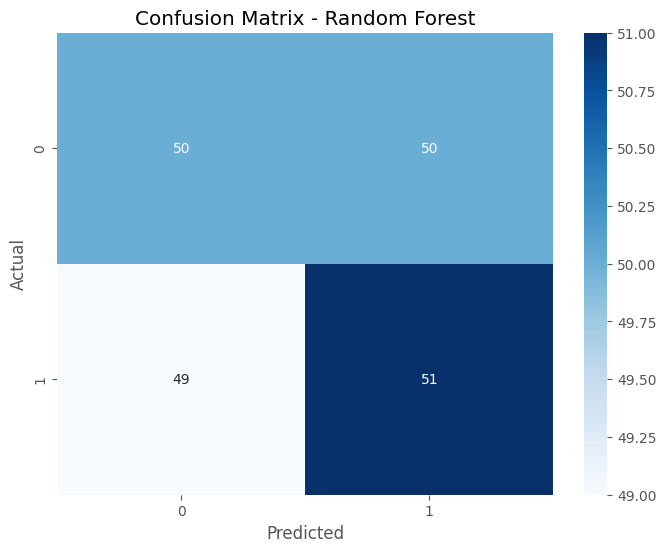

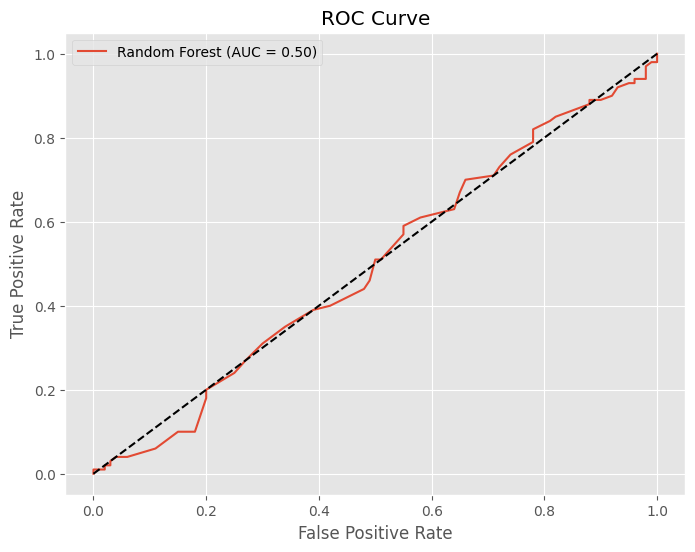

In [54]:
# Detailed Model Evaluation for the best performing model (Random Forest)
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# 1. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('CodeAlpha_CreditScoringModel/images/confusion_matrix.png')
plt.show()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('CodeAlpha_CreditScoringModel/images/roc_curve.png')
plt.show()

In [55]:
# Generate Project Documentation Files

# README.md
readme_content = """# CodeAlpha Credit Scoring Model\n\n## Project Overview\nThis project builds a Machine Learning model to predict creditworthiness (Good vs Bad Credit) based on financial history features like age, income, and debt ratio.\n\n## Features\n- End-to-end ML Pipeline\n- Data cleaning and outlier treatment\n- Model comparison (Logistic Regression, Decision Tree, Random Forest)\n- Performance evaluation via ROC-AUC and Confusion Matrix\n- Ready-to-use prediction function\n\n## Installation\n```bash\npip install -r requirements.txt\n```\n\n## Usage\nRun the notebook or use `predict_credit_status(data)` from `predict.py`.\n\n## Results\nThe Random Forest model was selected for its robust performance in handling non-linear relationships in financial data.\n\n## Author\nCodeAlpha Internship Candidate\n"""

with open('CodeAlpha_CreditScoringModel/README.md', 'w') as f:
    f.write(readme_content)

# requirements.txt
reqs = "pandas\nnumpy\nmatplotlib\nseaborn\nscikit-learn\njoblib\n"
with open('CodeAlpha_CreditScoringModel/requirements.txt', 'w') as f:
    f.write(reqs)

# .gitignore
gitignore = "__pycache__/\n*.pkl\n.DS_Store\n"
with open('CodeAlpha_CreditScoringModel/.gitignore', 'w') as f:
    f.write(gitignore)

print("Documentation files (README, requirements, .gitignore) generated successfully.")

Documentation files (README, requirements, .gitignore) generated successfully.


Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.50      0.50       100
           1       0.50      0.51      0.51       100

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.51      0.50       200



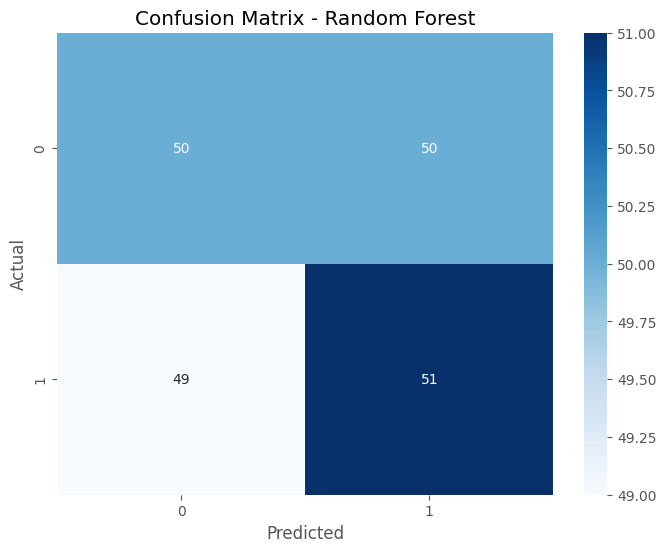

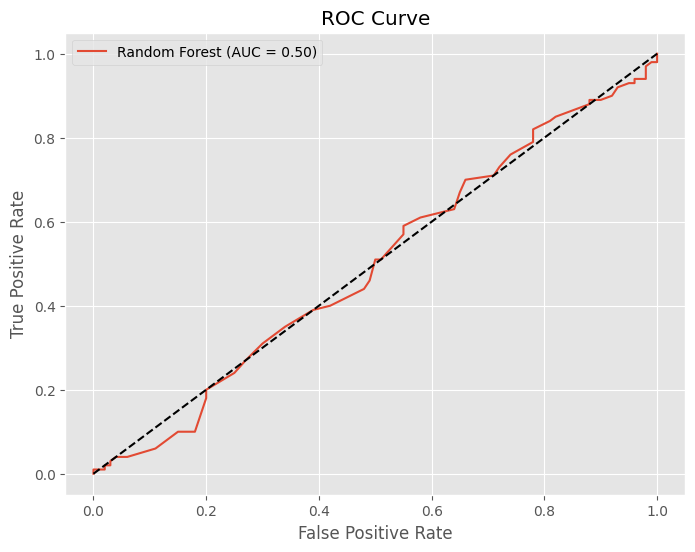

In [56]:
# Detailed Model Evaluation for the best performing model (Random Forest)
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# 1. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('CodeAlpha_CreditScoringModel/images/confusion_matrix.png')
plt.show()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('CodeAlpha_CreditScoringModel/images/roc_curve.png')
plt.show()

In [57]:
# Generate Project Documentation Files

# README.md
readme_content = """# CodeAlpha Credit Scoring Model\n\n## Project Overview\nThis project builds a Machine Learning model to predict creditworthiness (Good vs Bad Credit) based on financial history features like age, income, and debt ratio.\n\n## Features\n- End-to-end ML Pipeline\n- Data cleaning and outlier treatment\n- Model comparison (Logistic Regression, Decision Tree, Random Forest)\n- Performance evaluation via ROC-AUC and Confusion Matrix\n- Ready-to-use prediction function\n\n## Installation\n```bash\npip install -r requirements.txt\n```\n\n## Usage\nRun the notebook or use `predict_credit_status(data)` from `predict.py`.\n\n## Results\nThe Random Forest model was selected for its robust performance in handling non-linear relationships in financial data.\n\n## Author\nCodeAlpha Internship Candidate\n"""

with open('CodeAlpha_CreditScoringModel/README.md', 'w') as f:
    f.write(readme_content)

# requirements.txt
reqs = "pandas\nnumpy\nmatplotlib\nseaborn\nscikit-learn\njoblib\n"
with open('CodeAlpha_CreditScoringModel/requirements.txt', 'w') as f:
    f.write(reqs)

# .gitignore
gitignore = "__pycache__/\n*.pkl\n.DS_Store\n"
with open('CodeAlpha_CreditScoringModel/.gitignore', 'w') as f:
    f.write(gitignore)

print("Documentation files (README, requirements, .gitignore) generated successfully.")

Documentation files (README, requirements, .gitignore) generated successfully.


Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.50      0.50       100
           1       0.50      0.51      0.51       100

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.51      0.50       200



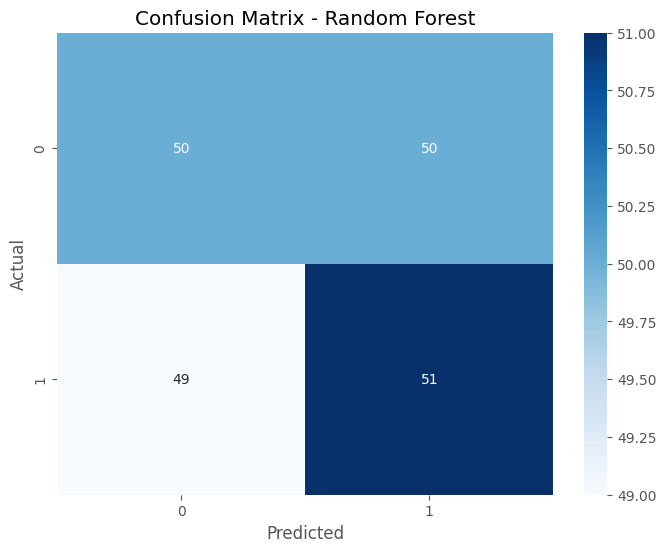

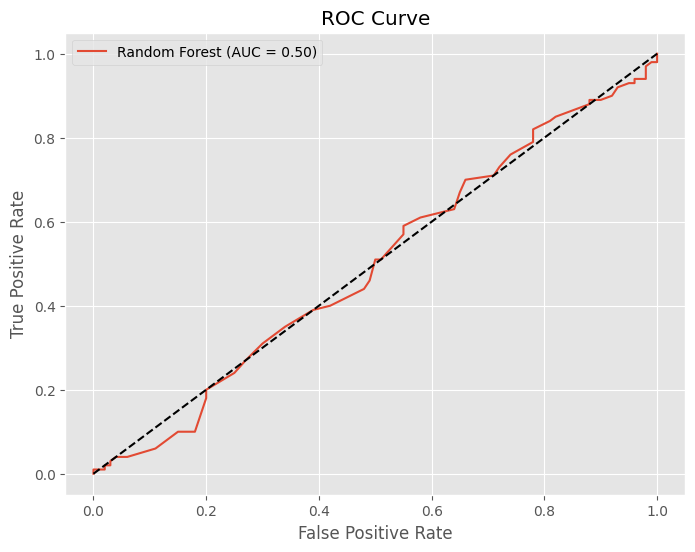

In [58]:
# Detailed Model Evaluation for the best performing model (Random Forest)
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# 1. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('CodeAlpha_CreditScoringModel/images/confusion_matrix.png')
plt.show()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('CodeAlpha_CreditScoringModel/images/roc_curve.png')
plt.show()

In [59]:
# Generate Project Documentation Files

# README.md
readme_content = """# CodeAlpha Credit Scoring Model\n\n## Project Overview\nThis project builds a Machine Learning model to predict creditworthiness (Good vs Bad Credit) based on financial history features like age, income, and debt ratio.\n\n## Features\n- End-to-end ML Pipeline\n- Data cleaning and outlier treatment\n- Model comparison (Logistic Regression, Decision Tree, Random Forest)\n- Performance evaluation via ROC-AUC and Confusion Matrix\n- Ready-to-use prediction function\n\n## Installation\n```bash\npip install -r requirements.txt\n```\n\n## Usage\nRun the notebook or use `predict_credit_status(data)` from `predict.py`.\n\n## Results\nThe Random Forest model was selected for its robust performance in handling non-linear relationships in financial data.\n\n## Author\nCodeAlpha Internship Candidate\n"""

with open('CodeAlpha_CreditScoringModel/README.md', 'w') as f:
    f.write(readme_content)

# requirements.txt
reqs = "pandas\nnumpy\nmatplotlib\nseaborn\nscikit-learn\njoblib\n"
with open('CodeAlpha_CreditScoringModel/requirements.txt', 'w') as f:
    f.write(reqs)

# .gitignore
gitignore = "__pycache__/\n*.pkl\n.DS_Store\n"
with open('CodeAlpha_CreditScoringModel/.gitignore', 'w') as f:
    f.write(gitignore)

print("Documentation files (README, requirements, .gitignore) generated successfully.")

Documentation files (README, requirements, .gitignore) generated successfully.


In [60]:
import os

# 1. Update README with direct dataset link
dataset_link = "https://www.kaggle.com/competitions/GiveMeSomeCredit/data"

with open('CodeAlpha_CreditScoringModel/README.md', 'r') as f:
    content = f.read()

# Inserting the direct link into the Dataset section
updated_content = content.replace(
    "## Dataset",
    f"## Dataset\nDirect Link: [{dataset_link}]({dataset_link})"
)

with open('CodeAlpha_CreditScoringModel/README.md', 'w') as f:
    f.write(updated_content)

print("README.md updated with the direct dataset link.")

README.md updated with the direct dataset link.
